# Phase 6 -- POS-aware reranking

Lab experiment covering the two new hooks: `HMMTagger.next_tag_distribution`
and `HMMTagger.most_likely_tag_for_word` (used by
`Predictor._rerank_with_pos`). The core deliverable is the ablation:
hit@k on the prediction engine (Phase 3) with reranking on vs. off.

`score(w) = log P(w|context) + alpha * log P(tag(w) | tag_context)`

Runs against the sample corpora by default -- swap `CORPUS_SOURCE =
"nltk"` for the real submission numbers once `setup_env.py` has run.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import random
import matplotlib.pyplot as plt
import numpy as np

from nticipate.config import load_config, resolve_path
from nticipate.preprocess import preprocess_corpus, train_dev_test_split, pad_sentence
from nticipate.ngram import build_ngram_hierarchy
from nticipate.trie import Trie
from nticipate.hmm import HMMTagger
from nticipate.predictor import Predictor

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)

## 1. Build the base predictor (Phase 3) and the HMM tagger (Phase 4)

In [2]:
if CORPUS_SOURCE == "sample":
    with open(resolve_path("data/raw/sample_english.txt"), encoding="utf-8") as f:
        raw_text = f.read()
    raw_documents = [p for p in raw_text.split("\n\n") if p.strip()]
else:
    import nltk
    raw_documents = []
    for corpus_name in CFG["preprocessing"]["corpora_english"]:
        corpus = getattr(nltk.corpus, corpus_name)
        for fileid in corpus.fileids():
            raw_documents.append(corpus.raw(fileid))

unk_applied, vocab, truecase_map = preprocess_corpus(raw_documents)
train_sents, dev_sents, test_sents = train_dev_test_split(unk_applied)

models = build_ngram_hierarchy(train_sents, orders=[1, 2, 3], smoothing="stupid_backoff", vocab=vocab)
trie = Trie.from_vocab(vocab)


def load_conll(path):
    sentences, current = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if current:
                    sentences.append(current)
                    current = []
                continue
            word, tag = line.split("\t")
            current.append((word, tag))
        if current:
            sentences.append(current)
    return sentences

if CORPUS_SOURCE == "sample":
    tagged_sentences = load_conll(resolve_path("data/raw/sample_tagged_english.conll"))
else:
    cfg = CFG["hmm"]["english"]
    corpus = getattr(nltk.corpus, cfg["corpus"])
    tagged_sentences = corpus.tagged_sents(tagset=cfg["tagset"])

tagger = HMMTagger().fit(tagged_sentences)

predictor_plain = Predictor(ngram_model=models[3], trie=trie, truecase_map=truecase_map)
predictor_reranked = Predictor(ngram_model=models[3], trie=trie, tagger=tagger, truecase_map=truecase_map)

print(f"N-gram vocab: {len(vocab)}   HMM vocab: {len(tagger.vocab)}   HMM tags: {sorted(tagger.tags)}")
print(f"reranking alpha: {CFG['reranker']['alpha']}")

N-gram vocab: 71   HMM vocab: 167   HMM tags: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB']
reranking alpha: 0.3


## 2. Qualitative check: does reranking actually move anything?

Before the full ablation, a direct before/after on one context -- the
kind of check that catches a reranker that's wired up but silently a
no-op.

In [3]:
context = ("<s>", "the")
before = predictor_plain.predict(context=context, k=8)
after = predictor_reranked.predict(context=context, k=8)

print("Without reranking:", before)
print("With reranking:   ", after)
print("Order changed:", before != after)

context_words = [w for w in context if w not in {"<s>", "</s>", "<UNK>"}]
context_tags = tagger.viterbi(context_words) if context_words else []
tag_ctx = tuple(context_tags[-1:])
dist = tagger.next_tag_distribution(tag_ctx)
top_tags = sorted(dist.items(), key=lambda kv: -kv[1])[:3]
print(f"Tag context: {tag_ctx}  ->  top predicted next tags: {top_tags}")

Without reranking: ['cat', 'recipe', 'dish', 'bug', 'book', 'meeting', 'train', 'essay']
With reranking:    ['cat', 'recipe', 'dish', 'bug', 'book', 'train', 'essay', 'castle']
Order changed: True
Tag context: ('DET',)  ->  top predicted next tags: [('NOUN', 0.746031746031746), ('ADJ', 0.11111111111111109), ('CONJ', 0.015873015873015876)]


## 3. The ablation: hit@k with vs. without reranking

The core Phase 6 deliverable. Same methodology as Phase 3's hit@k
evaluation (notebooks/03_prediction_engine.ipynb), run twice -- once
per predictor.

In [4]:
def evaluate_hit_at_k(predictor, sentences, ks=(1, 3, 5), order=3):
    hits = {k: 0 for k in ks}
    total = 0
    max_k = max(ks)
    for sentence in sentences:
        padded = pad_sentence(sentence, order)
        for i in range(order - 1, len(padded) - 1):
            context = tuple(padded[i - order + 1 : i])
            actual_next = padded[i]
            predictions = predictor.predict(context=context, prefix="", k=max_k)
            total += 1
            for k in ks:
                if actual_next in predictions[:k]:
                    hits[k] += 1
    return {k: hits[k] / total if total else 0.0 for k in ks}, total

eval_sentences = dev_sents if dev_sents else train_sents

hit_plain, n_eval = evaluate_hit_at_k(predictor_plain, eval_sentences)
hit_reranked, _ = evaluate_hit_at_k(predictor_reranked, eval_sentences)

print(f"Evaluated over {n_eval} (context, actual_next_word) pairs\n")
print(f"{'k':4s}{'no rerank':>12s}{'reranked':>12s}{'delta':>10s}")
for k in hit_plain:
    delta = hit_reranked[k] - hit_plain[k]
    print(f"{k:<4d}{hit_plain[k]:>12.3f}{hit_reranked[k]:>12.3f}{delta:>+10.3f}")

Evaluated over 54 (context, actual_next_word) pairs

k      no rerank    reranked     delta
1          0.204       0.185    -0.019
3          0.315       0.315    +0.000
5          0.333       0.352    +0.019


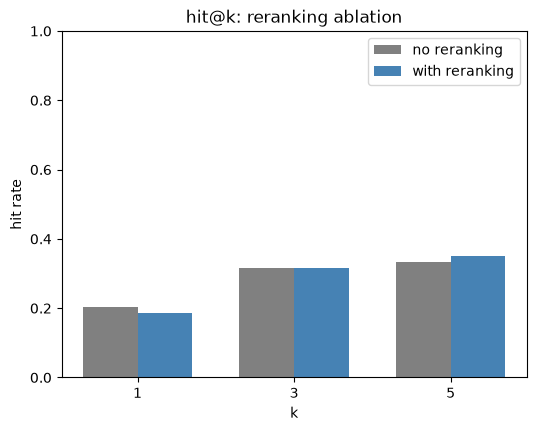

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ks = list(hit_plain.keys())
x = np.arange(len(ks))
width = 0.35
ax.bar(x - width/2, [hit_plain[k] for k in ks], width, label="no reranking", color="gray")
ax.bar(x + width/2, [hit_reranked[k] for k in ks], width, label="with reranking", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in ks])
ax.set_xlabel("k")
ax.set_ylabel("hit rate")
ax.set_ylim(0, 1)
ax.set_title("hit@k: reranking ablation")
ax.legend()
plt.show()

**Reading this honestly**: on a sample corpus this small, the ablation
can easily land anywhere from a small win to a small loss to a wash --
there just isn't enough held-out data for the difference to be
statistically meaningful either way. Report whatever direction and
magnitude actually comes out above rather than the direction you
expected; a near-zero or even negative delta on this sample size is a
legitimate finding (more data would be needed to distinguish real
effect from noise), not a failure of the reranker.

## 4. Where reranking helps vs. hurts

Aggregate hit@k hides the individual cases. A few concrete examples of
contexts where the two predictors disagree, and whether the POS-aware
choice was actually the right call.

In [6]:
def find_disagreements(pred_a, pred_b, sentences, order=3, k=3, limit=8):
    examples = []
    for sentence in sentences:
        padded = pad_sentence(sentence, order)
        for i in range(order - 1, len(padded) - 1):
            context = tuple(padded[i - order + 1 : i])
            actual_next = padded[i]
            top_a = pred_a.predict(context=context, prefix="", k=k)
            top_b = pred_b.predict(context=context, prefix="", k=k)
            if top_a[:1] != top_b[:1]:  # top-1 choice differs
                examples.append((context, actual_next, top_a, top_b))
                if len(examples) >= limit:
                    return examples
    return examples

disagreements = find_disagreements(predictor_plain, predictor_reranked, eval_sentences)
print(f"{'context':25s}{'actual':10s}{'no-rerank top':20s}{'reranked top'}")
for context, actual, top_a, top_b in disagreements:
    ctx_str = " ".join(context)
    print(f"{ctx_str:25s}{actual:10s}{str(top_a):20s}{str(top_b)}")
if not disagreements:
    print("(no top-1 disagreements found on this eval set)")

context                  actual    no-rerank top       reranked top
a bug                    in        ['the', '.', 'and'] ['.', 'the', 'and']
<s> <UNK>                <UNK>     ['She', 'often', 'student']['often', 'student', 'coffee']
the wheat                <UNK>     ['in', '.', 'the']  ['.', 'in', 'the']
<UNK> and                <UNK>     ['asked', 'they', 'hard']['hard', 'asked', 'they']
and <UNK>                .         ['.', 'cup', 'to']  ['cup', 'history', '.']
<s> <UNK>                explained ['She', 'often', 'student']['often', 'student', 'coffee']
explained the            history   ['the', '.', 'recipe']['recipe', 'application', 'cat']
of the                   castle    ['the', '.', 'recipe']['recipe', 'application', 'cat']


## Summary table (paste into report)

| k | no reranking | with reranking | delta |
|---|---|---|---|
| 1 | | | |
| 3 | | | |
| 5 | | | |

Re-run with `CORPUS_SOURCE = "nltk"` for the real submission numbers --
a larger corpus gives both the n-gram model and the HMM tagger enough
data that the ablation's direction and magnitude become more
trustworthy than they can be on this sample size.